In [1]:
import sys
print(sys.executable)

c:\Users\VolkovVaV\Desktop\thesis_grinding_model\.venv\Scripts\python.exe


In [1]:
import numpy, pandas, yaml, scipy, matplotlib
print("ok")

ok


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import yaml

from src.streams import Stream, normalize_psd
from src.units.mill import SimpleGrindingMill
from src.units.screen import ProtectiveScreen2mm
from src.units.knelson import Knelson
from src.units.cyclone import CyclonePartition
from src.solver import solve_flowsheet

In [2]:
from pathlib import Path
import sys

print("Notebook cwd:", Path().resolve())
print("First sys.path:", sys.path[:5])

Notebook cwd: C:\Users\VolkovVaV\Desktop\thesis_grinding_model\notebooks
First sys.path: ['C:\\Users\\VolkovVaV\\AppData\\Local\\Programs\\Python\\Python313\\python313.zip', 'C:\\Users\\VolkovVaV\\AppData\\Local\\Programs\\Python\\Python313\\DLLs', 'C:\\Users\\VolkovVaV\\AppData\\Local\\Programs\\Python\\Python313\\Lib', 'C:\\Users\\VolkovVaV\\AppData\\Local\\Programs\\Python\\Python313', 'c:\\Users\\VolkovVaV\\Desktop\\thesis_grinding_model\\.venv']


In [7]:
import importlib
import src.streams as s

importlib.reload(s)

print("streams file:", s.__file__)
print("dir(streams) has Stream?:", "Stream" in dir(s))
print("Top names:", [name for name in dir(s) if name[0].isupper()][:20])

streams file: C:\Users\VolkovVaV\Desktop\thesis_grinding_model\src\streams.py
dir(streams) has Stream?: True
Top names: ['Stream']


In [9]:
psd_df = pd.read_csv(PROJECT_ROOT / "data" / "feed_psd.csv")
psd = normalize_psd(psd_df["frac"].to_numpy())

d_top = psd_df["d_top_mm"].to_numpy()
d_bot = psd_df["d_bottom_mm"].to_numpy()
d_eff = np.sqrt(d_top * np.where(d_bot > 0, d_bot, 0.01))  # 0.01 мм для нижнего 0

water = yaml.safe_load((PROJECT_ROOT / "data" / "water_additions.yaml").read_text(encoding="utf-8"))
base = yaml.safe_load((PROJECT_ROOT / "data" / "base_case.yaml").read_text(encoding="utf-8"))

fresh_solid_tph = base["fresh_solid_tph"]
fresh_water_m3h = water["ore_moisture_m3h"] + water["sag_feed_dilution_m3h"]
fresh_feed = Stream(fresh_solid_tph, fresh_water_m3h, psd)

sag_mill = SimpleGrindingMill(base["sag_grinding_intensity"])
bm_mill  = SimpleGrindingMill(base["bm_grinding_intensity"])

screen3015 = ProtectiveScreen2mm(
    oversize_share_of_top_class=base["screen3015_oversize_share_of_top_class"],
    spray_water_m3h=water["screen3015_spray_m3h"]
)

kn = Knelson(
    concentrate_solid_tph=base["knelson_concentrate_solid_tph"],
    fluid_water_m3h=base["knelson_fluidization_water_m3h"]
)

cy = CyclonePartition(
    d50_mm=base["cyclone_d50_mm"],
    sharpness=base["cyclone_sharpness"],
    bypass=base["cyclone_bypass"],
    sizes_mm=d_eff
)

res = solve_flowsheet(
    fresh_feed=fresh_feed,
    sag_mill=sag_mill,
    bm_mill=bm_mill,
    screen3015=screen3015,
    knelson=kn,
    cyclone=cy,
    water_to_3012_m3h=water["sump_3012_water_m3h"],
    water_to_3017_extra_m3h=0.0,
    water_to_cyclone_feed_m3h=water["cyclone_feed_dilution_m3h"],
    bm_feed_dilution_m3h=water["bm_feed_dilution_m3h"],
    bm_discharge_transport_m3h=water["bm_discharge_transport_m3h"],
    relax=base["solver"]["relax"],
    max_iter=base["solver"]["max_iter"],
    tol_rel=base["solver"]["tol_rel_solid"],
)

print("Iterations:", res["iterations"])
print("Knelson feed (screen undersize) solid tph:", res["screen_us"].solid_tph)
print("Knelson concentrate solid tph:", res["kn_conc"].solid_tph)
print("Cyclone overflow solid tph:", res["cyclone_of"].solid_tph)
print("Cyclone underflow solid tph:", res["cyclone_uf"].solid_tph)

Iterations: 59
Knelson feed (screen undersize) solid tph: 720.2937933534301
Knelson concentrate solid tph: 0.147
Cyclone overflow solid tph: 135.9155493079044
Cyclone underflow solid tph: 584.2312440455257


In [10]:
def row(name, s):
    return {
        "stream": name,
        "solid_tph": s.solid_tph,
        "water_m3h": s.water_m3h,
    }

table = pd.DataFrame([
    row("fresh_feed_to_SAG", fresh_feed),
    row("sump3012", res["sump3012"]),
    row("screen3015_undersize (to Knelson)", res["screen_us"]),
    row("screen3015_oversize (to BM)", res["screen_os"]),
    row("knelson_tail (to sump3017)", res["kn_tail"]),
    row("knelson_concentrate (out)", res["kn_conc"]),
    row("sump3017", res["sump3017"]),
    row("cyclone_overflow (out)", res["cyclone_of"]),
    row("cyclone_underflow (to BM)", res["cyclone_uf"]),
])

table

,stream,solid_tph,water_m3h
0,fresh_feed_to_SAG,136.490000,40.54
1,sump3012,726.508267,321.50
2,screen3015_undersize (to Knelson),720.293793,425.99
3,screen3015_oversize (to BM),6.214474,0.00
4,knelson_tail (to sump3017),720.146793,505.99
5,knelson_concentrate (out),0.147000,0.00
6,sump3017,720.146793,505.99
7,cyclone_overflow (out),135.915549,578.71
8,cyclone_underflow (to BM),584.231244,0.00


In [12]:
for d50 in [0.10, 0.12, 0.14, 0.16]:
    cy = CyclonePartition(
        d50_mm=d50,
        sharpness=base["cyclone_sharpness"],
        bypass=base["cyclone_bypass"],
        sizes_mm=d_eff
    )
    res_tmp = solve_flowsheet(
        fresh_feed=fresh_feed,
        sag_mill=sag_mill,
        bm_mill=bm_mill,
        screen3015=screen3015,
        knelson=kn,
        cyclone=cy,
        water_to_3012_m3h=water["sump_3012_water_m3h"],
        water_to_3017_extra_m3h=0.0,
        water_to_cyclone_feed_m3h=water["cyclone_feed_dilution_m3h"],
        bm_feed_dilution_m3h=water["bm_feed_dilution_m3h"],
        bm_discharge_transport_m3h=water["bm_discharge_transport_m3h"],
        relax=float(base["solver"]["relax"]),
        max_iter=int(base["solver"]["max_iter"]),
        tol_rel=float(base["solver"]["tol_rel_solid"]),
    )
    print(d50, "Knelson feed tph =", res_tmp["screen_us"].solid_tph,
          "UF tph =", res_tmp["cyclone_uf"].solid_tph)

0.1 Knelson feed tph = 720.2937933534301 UF tph = 584.2312440455257
0.12 Knelson feed tph = 651.8575271320533 UF tph = 515.7835889351247
0.14 Knelson feed tph = 596.396982880939 UF tph = 460.3097569648133
0.16 Knelson feed tph = 550.7271322217144 UF tph = 414.6346333680345


In [13]:
target = base["knelson_feed_solid_tph_target"]

for d50 in [0.125, 0.1275, 0.13, 0.1325, 0.135]:
    cy = CyclonePartition(
        d50_mm=d50,
        sharpness=base["cyclone_sharpness"],
        bypass=base["cyclone_bypass"],
        sizes_mm=d_eff
    )
    res_tmp = solve_flowsheet(
        fresh_feed=fresh_feed,
        sag_mill=sag_mill,
        bm_mill=bm_mill,
        screen3015=screen3015,
        knelson=kn,
        cyclone=cy,
        water_to_3012_m3h=water["sump_3012_water_m3h"],
        water_to_3017_extra_m3h=0.0,
        water_to_cyclone_feed_m3h=water["cyclone_feed_dilution_m3h"],
        bm_feed_dilution_m3h=water["bm_feed_dilution_m3h"],
        bm_discharge_transport_m3h=water["bm_discharge_transport_m3h"],
        relax=float(base["solver"]["relax"]),
        max_iter=int(base["solver"]["max_iter"]),
        tol_rel=float(base["solver"]["tol_rel_solid"]),
    )
    kn_feed = res_tmp["screen_us"].solid_tph
    err = kn_feed - target
    print(f"d50={d50:.4f}  Knelson feed={kn_feed:.2f}  error={err:+.2f}")

d50=0.1250  Knelson feed=636.91  error=+9.73
d50=0.1275  Knelson feed=629.69  error=+2.51
d50=0.1300  Knelson feed=622.71  error=-4.47
d50=0.1325  Knelson feed=615.90  error=-11.28
d50=0.1350  Knelson feed=609.20  error=-17.98


In [14]:
for d50 in [0.1280, 0.1283, 0.1285, 0.1287, 0.1290]:
    cy = CyclonePartition(
        d50_mm=d50,
        sharpness=base["cyclone_sharpness"],
        bypass=base["cyclone_bypass"],
        sizes_mm=d_eff
    )
    res_tmp = solve_flowsheet(
        fresh_feed=fresh_feed,
        sag_mill=sag_mill,
        bm_mill=bm_mill,
        screen3015=screen3015,
        knelson=kn,
        cyclone=cy,
        water_to_3012_m3h=water["sump_3012_water_m3h"],
        water_to_3017_extra_m3h=0.0,
        water_to_cyclone_feed_m3h=water["cyclone_feed_dilution_m3h"],
        bm_feed_dilution_m3h=water["bm_feed_dilution_m3h"],
        bm_discharge_transport_m3h=water["bm_discharge_transport_m3h"],
        relax=float(base["solver"]["relax"]),
        max_iter=int(base["solver"]["max_iter"]),
        tol_rel=float(base["solver"]["tol_rel_solid"]),
    )
    kn_feed = res_tmp["screen_us"].solid_tph
    print(f"d50={d50:.4f}  Knelson feed={kn_feed:.2f}  error={kn_feed-627.18:+.2f}")

d50=0.1280  Knelson feed=628.28  error=+1.10
d50=0.1283  Knelson feed=627.44  error=+0.26
d50=0.1285  Knelson feed=626.88  error=-0.30
d50=0.1287  Knelson feed=626.32  error=-0.86
d50=0.1290  Knelson feed=625.48  error=-1.70


In [15]:
import pandas as pd

def row(name, s):
    return {
        "Поток": name,
        "Твёрдое, т/ч": float(s.solid_tph),
        "Вода, м3/ч": float(s.water_m3h),
    }

table = pd.DataFrame([
    row("Питание МПСИ (fresh feed)", fresh_feed),
    row("Зумпф 3012 (после смешения)", res["sump3012"]),
    row("Грохот 3015: подрешётный (на Knelson)", res["screen_us"]),
    row("Грохот 3015: надрешётный (в МШЦ)", res["screen_os"]),
    row("Knelson: хвосты (в 3017)", res["kn_tail"]),
    row("Knelson: концентрат (вывод)", res["kn_conc"]),
    row("Зумпф 3017", res["sump3017"]),
    row("Гидроциклон: слив (вывод из узла)", res["cyclone_of"]),
    row("Гидроциклон: пески (в МШЦ)", res["cyclone_uf"]),
])

# добавим строку с ошибкой по целевому значению Knelson feed
target = float(base["knelson_feed_solid_tph_target"])
kn_feed = float(res["screen_us"].solid_tph)
err = kn_feed - target

print(f"Контроль: Knelson feed = {kn_feed:.2f} т/ч, target = {target:.2f} т/ч, ошибка = {err:+.2f} т/ч")
table

Контроль: Knelson feed = 720.29 т/ч, target = 627.18 т/ч, ошибка = +93.11 т/ч


,Поток,"Твёрдое, т/ч","Вода, м3/ч"
0,Питание МПСИ (fresh feed),136.490000,40.54
1,Зумпф 3012 (после смешения),726.508267,321.50
2,Грохот 3015: подрешётный (на Knelson),720.293793,425.99
3,Грохот 3015: надрешётный (в МШЦ),6.214474,0.00
4,Knelson: хвосты (в 3017),720.146793,505.99
5,Knelson: концентрат (вывод),0.147000,0.00
6,Зумпф 3017,720.146793,505.99
7,Гидроциклон: слив (вывод из узла),135.915549,578.71
8,Гидроциклон: пески (в МШЦ),584.231244,0.00


In [16]:
import numpy as np
import matplotlib.pyplot as plt

d50_grid = np.array([0.10, 0.12, 0.14, 0.16, 0.125, 0.1275, 0.130, 0.1325, 0.135,
                     0.1280, 0.1283, 0.1285, 0.1287, 0.1290])
d50_grid = np.unique(np.sort(d50_grid))

results = []

for d50 in d50_grid:
    cy_tmp = CyclonePartition(
        d50_mm=float(d50),
        sharpness=base["cyclone_sharpness"],
        bypass=base["cyclone_bypass"],
        sizes_mm=d_eff
    )

    res_tmp = solve_flowsheet(
        fresh_feed=fresh_feed,
        sag_mill=sag_mill,
        bm_mill=bm_mill,
        screen3015=screen3015,
        knelson=kn,
        cyclone=cy_tmp,
        water_to_3012_m3h=water["sump_3012_water_m3h"],
        water_to_3017_extra_m3h=0.0,
        water_to_cyclone_feed_m3h=water["cyclone_feed_dilution_m3h"],
        bm_feed_dilution_m3h=water["bm_feed_dilution_m3h"],
        bm_discharge_transport_m3h=water["bm_discharge_transport_m3h"],
        relax=float(base["solver"]["relax"]),
        max_iter=int(base["solver"]["max_iter"]),
        tol_rel=float(base["solver"]["tol_rel_solid"]),
    )

    results.append({
        "d50_mm": float(d50),
        "knelson_feed_tph": float(res_tmp["screen_us"].solid_tph),
        "cyclone_uf_tph": float(res_tmp["cyclone_uf"].solid_tph),
        "cyclone_of_tph": float(res_tmp["cyclone_of"].solid_tph),
        "iterations": int(res_tmp["iterations"])
    })

df_sens = pd.DataFrame(results).sort_values("d50_mm").reset_index(drop=True)
df_sens

,d50_mm,knelson_feed_tph,cyclone_uf_tph,cyclone_of_tph,iterations
0,0.1000,720.293793,584.231244,135.915549,59
1,0.1200,651.857527,515.783589,135.926938,55
2,0.1250,636.908864,500.833871,135.927992,54
3,0.1275,629.692773,493.624292,135.921481,53
4,0.1280,628.281699,492.211788,135.922911,53
5,0.1283,627.438459,491.367701,135.923758,53
6,0.1285,626.877713,490.806394,135.924318,53
7,0.1287,626.318092,490.246217,135.924875,53
8,0.1290,625.480767,489.408064,135.925704,53
9,0.1300,622.707809,486.632400,135.928409,53


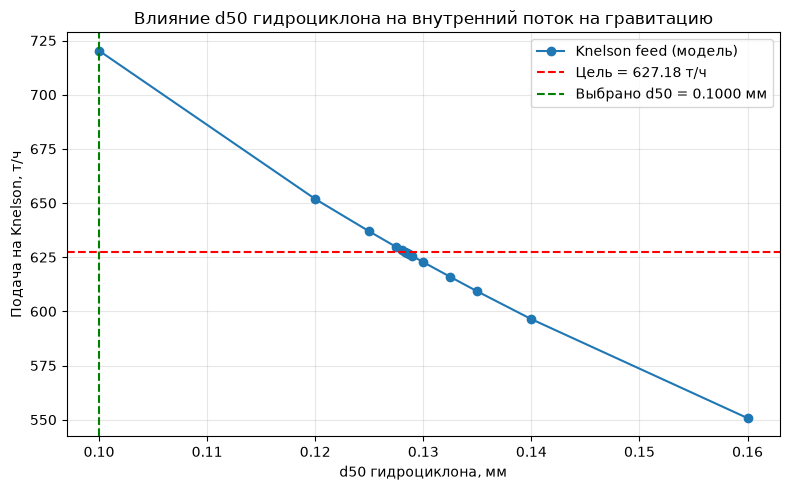

In [ ]:
target = float(base["knelson_feed_solid_tph_target"])
d50_chosen = float(base["cyclone_d50_mm"])

plt.figure(figsize=(8,5))
plt.plot(df_sens["d50_mm"], df_sens["knelson_feed_tph"], marker="o", label="Knelson feed (модель)")
plt.axhline(target, color="red", linestyle="--", label=f"Цель = {target:.2f} т/ч")
plt.axvline(d50_chosen, color="green", linestyle="--", label=f"Выбрано d50 = {d50_chosen:.4f} мм")

plt.xlabel("d50 гидроциклона, мм")
plt.ylabel("Подача на Knelson, т/ч")
plt.title("Влияние d50 гидроциклона на внутренний поток на гравитацию")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()